In [1]:
import qutip as qt
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

## general solution for g(t)

In [2]:
# Define temporal mode
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

kappa = 2.5e-3*2*np.pi*2

def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

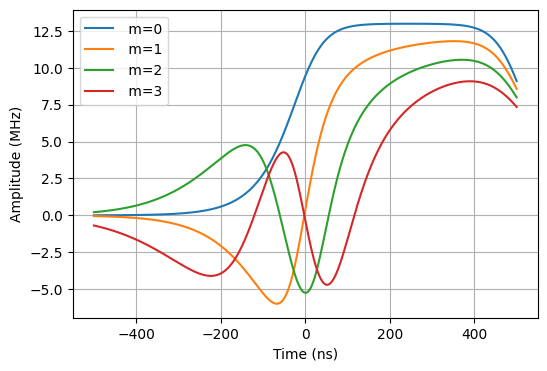

In [3]:
# define g(t)
def f(t, m, kappa):
    return xi_m(t, m, kappa)

def f_prime(t, m, kappa, h=1e-3):
    return (f(t + h, m, kappa) - f(t - h, m, kappa)) / (2 * h)

def compute_g(t_vals, m, kappa, kappa_ph):
    f_vals = f(t_vals, m, kappa_ph)
    f_prime_vals = f_prime(t_vals, m, kappa_ph)
    

    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, t_vals, initial=0)
    
    numerator = f_prime_vals + (kappa * f_vals / 2)
    denominator = np.sqrt(kappa * (1 - integral_vals) - f2_vals)
    
    return numerator / denominator

kappa =  0.14*2*np.pi
kappa_ph = 2.5e-3*2*np.pi*2
t_vals = np.linspace(-500, 500, 501)

plt.figure(figsize=(6, 4))
for m in range(4):
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, np.real(g_vals)/2/np.pi*1e3, label=fr" m={m}")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()


## QuTiP simulation

In [4]:
from process_tomography import *
from state_tomography import *
from libys import qtp as ysq
from datataking import search_datadict_miyamura
from qutip import fidelity, Qobj

In [5]:
# define the system (b: qubit, a: resonator, vc: virtual cavity)
n_cutoff_q = 3
n_cutoff_r = 2
n_cutoff_vc = 3

b = qt.tensor(qt.destroy(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
a = qt.tensor(qt.qeye(n_cutoff_q), qt.destroy(n_cutoff_r), qt.qeye(n_cutoff_vc))
vc = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.destroy(n_cutoff_vc))

g0 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
f0 = qt.tensor(qt.basis(n_cutoff_q, 2), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
g1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 1), qt.basis(n_cutoff_vc, 0))
e0 = qt.tensor(qt.basis(n_cutoff_q, 1), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
vc1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1))

alpha = -0.356 * 2 * np.pi
chi = -0.0076 * 2 * np.pi
eta = 0.67
kappa_r = 0.14 * 2 * np.pi
K = 0 * 2 * np.pi

H_fogi = (
    -alpha / 2 * b.dag()*b + alpha * b.dag()*b.dag()*b*b / 2
    +K * a.dag()*a.dag()*a*a / 2 + 2*chi*a.dag()*a*b.dag()*b
)
H_d = -a.dag()*b*b/np.sqrt(2)
H_c = 1j * (np.sqrt(kappa_r)/2) * vc.dag()*a


In [6]:
# aquire g (coupling between f0-g1) and g_u (coupling between virtual cavity and resonator)
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 500 
N = 501
tgrid = np.linspace(-T, T, N)
dt = tgrid[1] - tgrid[0]
kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

g_interps = []
g_interps_rvs = []

for m in range(4): 
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    numerator = f_prime_vals + (kappa_r * f_vals / 2)
    denominator = np.sqrt(kappa_r * (1.0 - integral_vals) - f2_vals)
    g_vals = numerator / denominator
    g_interp = interp1d(tgrid, np.real(g_vals), kind='cubic', fill_value='extrapolate')
    g_interps.append(g_interp)

    g_interp_rvs = interp1d(tgrid, np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_interps_rvs.append(g_interp_rvs)
    
g_u_interps = []
for m in range(4):
    ut_vals = xi_m(tgrid, m, kappa_ph)
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u_interps.append(g_interp)

def g_u(t, args):
    m = int(args["input_num"])
    t_local = float(t)
    return float(args["g_u_interps"][m](t_local))

def g_u_conj(t, args):
    return np.conjugate(g_u(t, args))

def g_time(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    return float(args["g_interps"][m](t_local))

def g_time_conj(t, args):
    return np.conjugate(g_time(t, args))

def g_time_rvs(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    return float(args["g_interps_rvs"][m](t_local))

def g_time_conj_rvs(t, args):
    return np.conjugate(g_time_rvs(t, args))

In [7]:
# define c_ops
T1ge=29*1e3
T1ef=22*1e3
T2ge=5*1e3
T2ef=5*1e3
Tphige=1/((1/T2ge-1/T1ge/2)/2)
Tphief=1/((1/T2ef-1/T1ef/2)/2)

gedecayop = qt.basis(n_cutoff_q, 0) * qt.basis(n_cutoff_q, 1).dag()
etog = qt.tensor(gedecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))

efdecayop = qt.basis(n_cutoff_q, 1) * qt.basis(n_cutoff_q, 2).dag()
ftoe = qt.tensor(efdecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))

gedechoop = (qt.basis(n_cutoff_q, 1)*qt.basis(n_cutoff_q, 1).dag()
             - qt.basis(n_cutoff_q, 0)*qt.basis(n_cutoff_q, 0).dag())
dechoge = qt.tensor(gedechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))

efdechoop = (qt.basis(n_cutoff_q, 2)*qt.basis(n_cutoff_q, 2).dag()
             - qt.basis(n_cutoff_q, 1)*qt.basis(n_cutoff_q, 1).dag())
dechoef = qt.tensor(efdechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))

### photon emission

In [8]:
base_args = {
    "center": 0.0,
    "fogi_mode": 2,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 0,
}
e_ops = []
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=True)
results = {} 

for m in range(4):
    args_m = base_args.copy()
    args_m["fogi_mode"] = m

    H_m = [
        H_fogi,
        [H_d, g_time], [H_d.dag(), g_time_conj], 
    ]
    psi0_m = (g0 + f0).unit()


    def total_c_op(t, args):
        c_op = np.sqrt(kappa_r) * a
        return c_op

    c_ops_m = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]

    result_m = qt.mesolve(
        H_m, psi0_m, tgrid, c_ops_m, e_ops=e_ops,
        args=args_m, options=options, progress_bar=True
    )

    results[m] = result_m
    print(f"mode {m} finished")

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:   0.41s. Est. time left: 00:00:00:03
20.0%. Run time:   0.79s. Est. time left: 00:00:00:03
30.0%. Run time:   1.20s. Est. time left: 00:00:00:02
40.0%. Run time:   1.58s. Est. time left: 00:00:00:02
50.0%. Run time:   1.96s. Est. time left: 00:00:00:01
60.0%. Run time:   2.33s. Est. time left: 00:00:00:01
70.0%. Run time:   2.80s. Est. time left: 00:00:00:01
80.0%. Run time:   3.26s. Est. time left: 00:00:00:00
90.0%. Run time:   3.63s. Est. time left: 00:00:00:00
100.0%. Run time:   3.99s. Est. time left: 00:00:00:00
Total run time:   3.99s
mode 0 finished
10.0%. Run time:   0.39s. Est. time left: 00:00:00:03
20.0%. Run time:   0.75s. Est. time left: 00:00:00:03
30.0%. Run time:   1.15s. Est. time left: 00:00:00:02
40.0%. Run time:   1.54s. Est. time left: 00:00:00:02
50.0%. Run time:   1.91s. Est. time left: 00:00:00:01
60.0%. Run time:   2.28s. Est. time left: 00:00:00:01
70.0%. Run time:   2.65s. Est. time left: 00:00:00:01
80.0%. Run time:   3.03s. Est. time left:

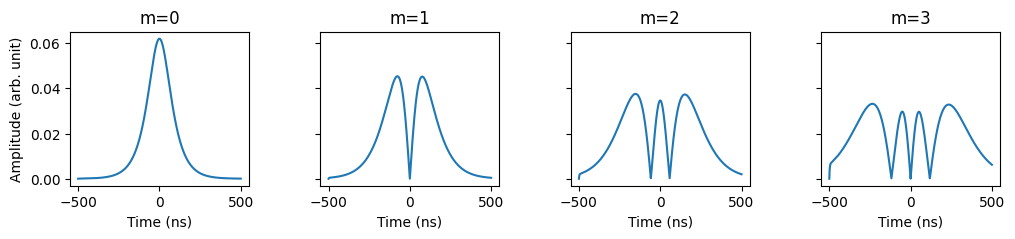

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(12, 2), sharey=True)
plt.subplots_adjust(wspace=0.4)

for i in range(4):
    states = results[i].states
    vcdvc_s = qt.expect(vc.dag() * vc, states)
    ada_s = qt.expect(a.dag() * a, states)
    vcda_s = qt.expect(vc.dag() * a, states)
    advc_s = qt.expect(a.dag() * vc, states)
    gu_values = np.array([g_u(t, base_args) for t in tgrid])
    LdL = (
        # gu_values * np.conjugate(gu_values) * vcdvc_s
        + kappa_r * ada_s
        # + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
    )
    axes[i].plot(tgrid, np.sqrt(LdL), label="photon waveform")
    axes[i].set_title(f"m={i}")
    axes[i].set_xlabel(r"Time (ns)")
    if i == 0:
        axes[i].set_ylabel("Amplitude (arb. unit)")
plt.show()

### photon absorption

In [14]:
base_args = {
    "center": 0.0,
    "fogi_mode": 0,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 1,
}
results = {} 

for m in range(4):
    args_mn = base_args.copy()
    args_mn["input_num"] = m

    for n in range(4):
        args_mn["fogi_mode"] = n
        H_m = [
            H_fogi,
            [H_c, g_u], [H_c.dag(), g_u_conj],
            [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
        ]
        psi0_m = vc1

        def total_c_op(t, args):
            c_op = np.conjugate(g_u(t, args)) * vc + np.sqrt(kappa_r) * a
            return c_op

        c_ops_mn = [
            total_c_op,
            np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
            np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
        ]

        result_mn = qt.mesolve(
            H_m, psi0_m, tgrid, c_ops_mn, e_ops=e_ops,
            args=args_mn, options=options, progress_bar=True
        )

        results[(m, n)] = result_mn 
    print(f"mode {m} finished")


10.0%. Run time:   0.49s. Est. time left: 00:00:00:04
20.0%. Run time:   1.08s. Est. time left: 00:00:00:04
30.0%. Run time:   1.61s. Est. time left: 00:00:00:03
40.0%. Run time:   2.28s. Est. time left: 00:00:00:03
50.0%. Run time:   2.75s. Est. time left: 00:00:00:02
60.0%. Run time:   3.19s. Est. time left: 00:00:00:02
70.0%. Run time:   3.70s. Est. time left: 00:00:00:01
80.0%. Run time:   4.25s. Est. time left: 00:00:00:01
90.0%. Run time:   4.76s. Est. time left: 00:00:00:00
100.0%. Run time:   5.34s. Est. time left: 00:00:00:00
Total run time:   5.34s
10.0%. Run time:   0.49s. Est. time left: 00:00:00:04
20.0%. Run time:   0.93s. Est. time left: 00:00:00:03
30.0%. Run time:   1.41s. Est. time left: 00:00:00:03
40.0%. Run time:   1.91s. Est. time left: 00:00:00:02
50.0%. Run time:   2.47s. Est. time left: 00:00:00:02
60.0%. Run time:   2.95s. Est. time left: 00:00:00:01
70.0%. Run time:   3.52s. Est. time left: 00:00:00:01
80.0%. Run time:   4.06s. Est. time left: 00:00:00:01
90.

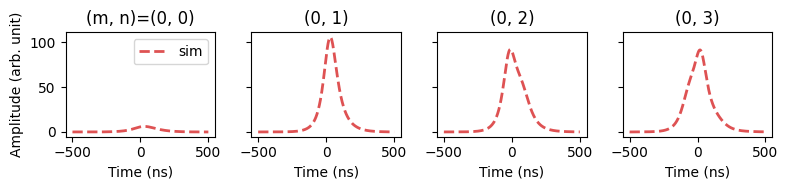

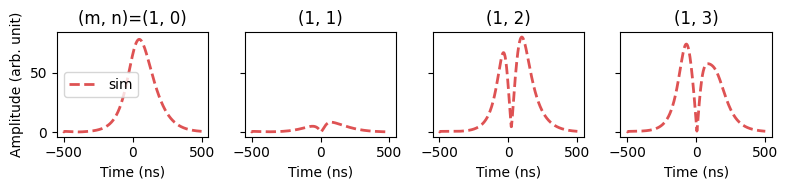

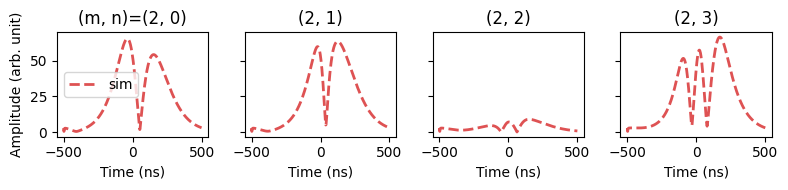

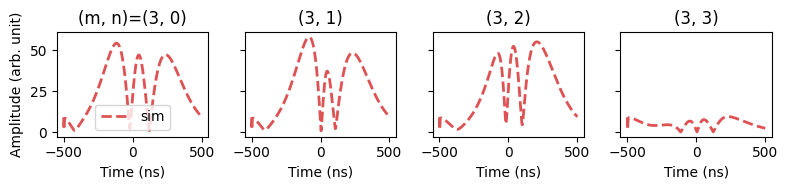

In [16]:
for m in range(4):    
    fig, axes = plt.subplots(1, 4, figsize=(8, 2), sharey=True)
    plt.subplots_adjust(wspace=0.4)

    for n in range(4):
        states = results[(m, n)].states
        vcdvc_s = qt.expect(vc.dag() * vc, states)
        ada_s = qt.expect(a.dag() * a, states)
        vcda_s = qt.expect(vc.dag() * a, states)
        advc_s = qt.expect(a.dag() * vc, states)
        args = {
            "center": 0.0,
            "fogi_mode": n,
            "g_interps": g_interps,
            "g_interps_rvs": g_interps_rvs,
            "g_u_interps": g_u_interps,
            "input_num": m,
            "input": 0,
        }  

        gu_values = np.array([g_u(t, args) for t in tgrid])
        LdL = (
            gu_values * np.conjugate(gu_values) * vcdvc_s
            + kappa_r * ada_s
            + np.sqrt(kappa_r) * (gu_values * vcda_s + np.conjugate(gu_values) * advc_s)
        )
        axes[n].plot(tgrid, np.abs(np.sqrt(LdL))*1e3, lw=2, alpha=0.8, linestyle="--", color="tab:red", label="sim")
        
        axes[n].set_xlabel(r"Time (ns)")
        if n == 0:
            axes[n].legend()
            axes[n].set_ylabel("Amplitude (arb. unit)")
            axes[n].set_title(f"(m, n)=({m}, {n})")
        else:
            axes[n].set_title(f"({m}, {n})")
    plt.tight_layout()
    plt.show()